# 03 — E-Explore

**Dikerjakan oleh:**

- Ghazy Achmed Movlech Urbayani (18223093) — Data Preprocessing Lead
- Muhammad Azizdzaki Khrisnanurmuflih (18223128) - Visualization / Dashboard Developer

**Kelompok 14 | II4013 Data Analitik**  
Cakupan: Eksplorasi data untuk Laporan Bab 4.

> Notebook ini membaca data bersih dari `data/processed/` (output `02_scrub.ipynb`).  
> Minimum 3 visualisasi dengan interpretasi tajam. Metode: statistik deskriptif,  
> distribusi, tren waktu, perbandingan kategori, hubungan antarvariabel.

In [62]:
# [AI-assisted] Setup Library, Path, dan Style Visualisasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 65)
pd.set_option('display.max_colwidth', 50)
pd.set_option('display.float_format', '{:.2f}'.format)

PROCESSED_PATH = '../data/processed/'
FIGURES_DIR    = '../reports/figures/'
os.makedirs(FIGURES_DIR, exist_ok=True)

plt.rcParams.update({
    'figure.dpi'       : 120,
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'xtick.labelsize'  : 9,
    'ytick.labelsize'  : 9,
    'legend.fontsize'  : 9,
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'figure.facecolor' : 'white',
})
PAL_CAT = 'Set2'
PAL_SEQ = 'Blues_r'
print('Setup selesai.')

Setup selesai.


## Load Data Bersih

In [63]:
# Load Data Processed dari 02_scrub.ipynb
df1          = pd.read_csv(PROCESSED_PATH + "ds1Clean.csv")
df_issues    = pd.read_csv(PROCESSED_PATH + "ds2IssuesClean.csv")
df_utterances= pd.read_csv(PROCESSED_PATH + "ds2UtterancesClean.csv")
df_scored    = pd.read_csv(PROCESSED_PATH + "ds2ScoredClean.csv")

# ds2SnapshotClean.csv punya baris tidak konsisten (kolom 45 vs 63) -> skip baris rusak
try:
    df_snapshot = pd.read_csv(PROCESSED_PATH + "ds2SnapshotClean.csv", on_bad_lines="skip")
except TypeError:
    # pandas < 1.3 belum support on_bad_lines, fallback ke error_bad_lines
    df_snapshot = pd.read_csv(PROCESSED_PATH + "ds2SnapshotClean.csv", error_bad_lines=False)

# Parse timestamp columns yang tersimpan sebagai string
TS_COLS_ISSUES = ["started_dt", "ended_dt", "issue_created_dt",
                  "issue_resolution_date_dt", "last_change_date_dt"]
for col in TS_COLS_ISSUES:
    if col in df_issues.columns:
        df_issues[col] = pd.to_datetime(df_issues[col], utc=True, errors="coerce")

datasets = {
    "ds1Clean"         : df1,
    "ds2IssuesClean"   : df_issues,
    "ds2UtterancesClean": df_utterances,
    "ds2ScoredClean"   : df_scored,
    "ds2SnapshotClean" : df_snapshot,
}
print("=== Data Loaded ===")
for name, df in datasets.items():
    print("  {:25s}: {:>7,} baris x {:>3} kolom".format(name, *df.shape))

=== Data Loaded ===
  ds1Clean                 : 100,000 baris x  22 kolom
  ds2IssuesClean           :  66,691 baris x  57 kolom
  ds2UtterancesClean       :  14,455 baris x  12 kolom
  ds2ScoredClean           :     747 baris x  21 kolom
  ds2SnapshotClean         :  90,904 baris x  45 kolom


## Statistik Deskriptif

Tabel mean/median/std/min/max variabel numerik utama + value counts kategorikal.

In [64]:
# 8A — Statistik Deskriptif DS1
NUM_DS1 = [c for c in ['daysOpen','resolutionDurationDays','severityLevel',
                        'priorityLevel','seniorityLevel','satisfactionLevel',
                        'isLongTicket','isHighPriority','priorityVerified'] if c in df1.columns]
print('=== DS1 — Statistik Deskriptif Numerik ===')
display(df1[NUM_DS1].describe().round(2))
print()
print('=== DS1 — Value Counts Kategorikal ===')
for col in ['FiledAgainst', 'TicketType', 'severityLabel', 'priorityLabel', 'seniorityLabel']:
    if col not in df1.columns: continue
    vc  = df1[col].value_counts()
    pct = (vc / len(df1) * 100).round(1)
    tbl = pd.DataFrame({'n': vc, '%': pct})
    print('  {}:'.format(col))
    print(tbl.to_string())
    print()

=== DS1 — Statistik Deskriptif Numerik ===


,daysOpen,resolutionDurationDays,severityLevel,priorityLevel,seniorityLevel,satisfactionLevel,isLongTicket,isHighPriority,priorityVerified
count,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00,100000.00
mean,6.80,6.80,2.05,1.59,2.38,1.48,0.04,0.36,0.53
std,7.24,7.24,0.38,1.25,1.02,1.20,0.21,0.48,0.50
min,0.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
25%,1.00,1.00,2.00,0.00,2.00,0.00,0.00,0.00,0.00
50%,5.00,5.00,2.00,2.00,2.00,1.00,0.00,0.00,1.00
75%,10.00,10.00,2.00,3.00,3.00,3.00,0.00,1.00,1.00
max,31.00,31.00,4.00,3.00,4.00,3.00,1.00,1.00,1.00



=== DS1 — Value Counts Kategorikal ===
  FiledAgainst:
                  n     %
FiledAgainst             
systems       40035 40.00
access/login  29921 29.90
software      20068 20.10
hardware       9976 10.00

  TicketType:
                n     %
TicketType             
request     75074 75.10
issue       24926 24.90

  severityLabel:
                   n     %
severityLabel             
normal         90912 90.90
major           4974  5.00
minor           2317  2.30
critical        1430  1.40
unclassified     367  0.40

  priorityLabel:
                   n     %
priorityLabel             
high           36498 36.50
unassigned     30127 30.10
low            17117 17.10
medium         16258 16.30

  seniorityLabel:
                    n     %
seniorityLabel             
regular         41303 41.30
junior          20040 20.00
management      19856 19.90
senior          18801 18.80



In [65]:
# 8A — Statistik Deskriptif DS2
NUM_DS2 = [c for c in ['totalTimeHours','resolutionDurationHours','processing_steps',
    'timePerStepHours','wf_resolved','wf_in_progress','wf_waiting',
    'wfe_reopened','issue_contr_count','issue_comments_count','utteranceCountPerIssue',
    'isResolved','isComplex','compositeScore'] if c in df_issues.columns]
print('=== DS2 — Statistik Deskriptif Numerik ===')
display(df_issues[NUM_DS2].describe().round(2))
print()
print('=== DS2 — Value Counts Kategorikal ===')
for col in ['issue_type','priorityNormalized','issue_status','resolutionSpeedCategory','performanceBinary']:
    if col not in df_issues.columns: continue
    vc  = df_issues[col].value_counts(dropna=False)
    pct = (vc / len(df_issues) * 100).round(1)
    tbl = pd.DataFrame({'n': vc, '%': pct})
    print('  {}:'.format(col))
    print(tbl.to_string())
    print()

=== DS2 — Statistik Deskriptif Numerik ===


,totalTimeHours,resolutionDurationHours,processing_steps,timePerStepHours,wf_resolved,wf_in_progress,wf_waiting,wfe_reopened,issue_contr_count,issue_comments_count,utteranceCountPerIssue,isResolved,isComplex,compositeScore
count,66691.00,65838.00,66691.00,66613.00,66691.00,66691.00,66691.00,66691.00,66691.00,66691.00,66691.00,66691.00,66691.00,360.00
mean,18255.18,18443.95,3.16,17450.43,140617.61,526645.01,507871.98,0.04,1.22,8.64,0.22,0.99,0.20,3.80
std,27594.26,27701.30,2.51,27581.19,1605470.43,3355838.68,2194563.47,0.21,0.53,13.79,4.13,0.11,0.40,1.97
min,0.00,0.00,0.00,0.00,0.00,-77.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,122.46,124.32,1.00,32.22,0.00,0.00,0.00,0.00,1.00,3.00,0.00,1.00,0.00,3.00
50%,822.77,837.81,3.00,204.66,0.00,5.01,0.00,0.00,1.00,5.00,0.00,1.00,0.00,5.00
75%,35921.94,36508.15,4.00,34154.95,14.00,59258.06,60350.02,0.00,1.00,10.00,0.00,1.00,0.00,5.00
max,90910.58,90928.99,13.00,90910.58,93810013.68,160846379.00,115585186.01,11.00,10.00,685.00,359.00,1.00,1.00,5.00



=== DS2 — Value Counts Kategorikal ===
  issue_type:
                    n     %
issue_type                 
ticket          45275 67.90
service          5300  7.90
subtask          4746  7.10
story            4538  6.80
hd service       1686  2.50
task             1540  2.30
vacation          856  1.30
project           842  1.30
sub-task          544  0.80
epic              403  0.60
deployment        350  0.50
retrospective     241  0.40
sprint summary    208  0.30
assistance        109  0.20
bug                53  0.10

  priorityNormalized:
                        n     %
priorityNormalized             
unknown             33965 50.90
medium              24788 37.20
high                 7294 10.90
low                   644  1.00

  issue_status:
                               n     %
issue_status                          
closed                     56344 84.50
done                        9714 14.60
waiting                      218  0.30
open                          97  0.10
in_p

## Distribusi

**Pertanyaan Analitik:** 
Bagaimana distribusi karakteristik tiket?  
Apakah ada class imbalance yang akan mempengaruhi model?

**Visualisasi 1:** Distribusi Severity & Priority (DS1) + issue_priority (DS2)

Saved: viz1_distribusi_severity_priority.png

=== Interpretasi Visualisasi 1 ===
- DS1 Severity: cek apakah "normal" mendominasi -> imbalance untuk model klasifikasi
- DS1 Priority: distribusi lebih merata vs Severity -> priority lebih baik sebagai target
- DS2 Priority: cek proporsi "unknown" pasca normalisasi -> kualitas data priority
- Imbalance > 10:1 -> class_weight atau SMOTE pada training split (scope Modeler)


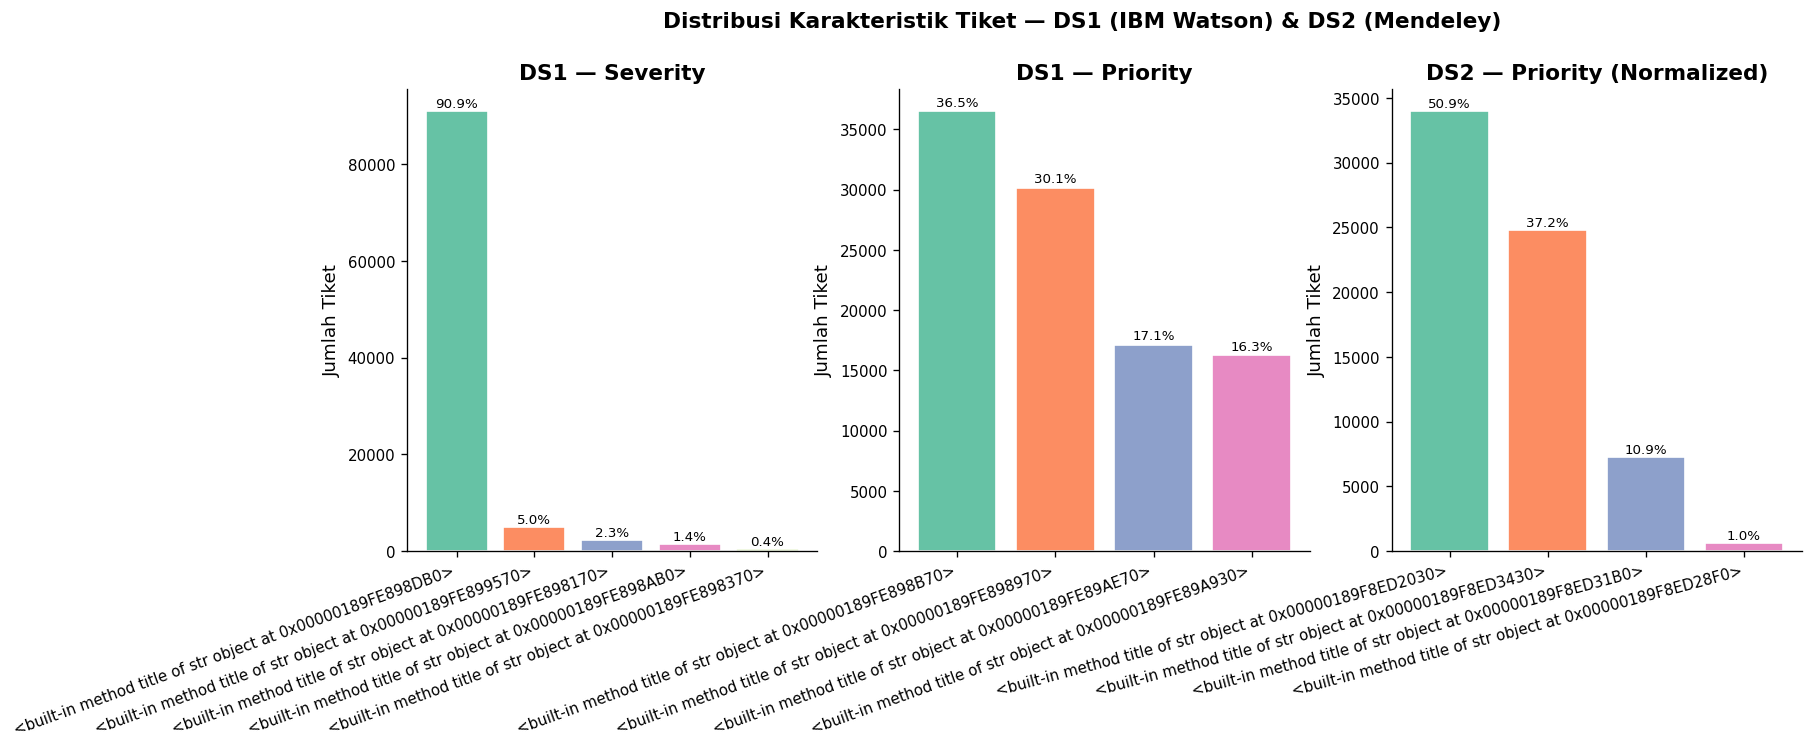

In [66]:
# 1 — Visualisasi 1: Distribusi Severity, Priority DS1 + DS2 (Grouped Bar)
# Kaitan pertanyaan analitik: "Bagaimana karakteristik distribusi tiket
#   ditinjau dari severity dan priority?"

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Distribusi Karakteristik Tiket — DS1 (IBM Watson) & DS2 (Mendeley)',
             fontsize=13, fontweight='bold', y=1.01)

# Panel 1: DS1 Severity
ax1 = axes[0]
if 'severityLabel' in df1.columns:
    sev_vc = df1['severityLabel'].value_counts().sort_values(ascending=False)
    clrs   = sns.color_palette(PAL_CAT, len(sev_vc))
    bars1  = ax1.bar(range(len(sev_vc)), sev_vc.values, color=clrs, edgecolor='white')
    ax1.set_xticks(range(len(sev_vc)))
    ax1.set_xticklabels([v.title for v in sev_vc.index], rotation=20, ha='right')
    ax1.set_title('DS1 — Severity', fontweight='bold')
    ax1.set_ylabel('Jumlah Tiket')
    for bar in bars1:
        ax1.text(bar.get_x()+bar.get_width()/2., bar.get_height()+200,
                 '{:.1f}%'.format(bar.get_height()/len(df1)*100),
                 ha='center', va='bottom', fontsize=8)

# Panel 2: DS1 Priority
ax2 = axes[1]
if 'priorityLabel' in df1.columns:
    pri_vc = df1['priorityLabel'].value_counts().sort_values(ascending=False)
    clrs2  = sns.color_palette(PAL_CAT, len(pri_vc))
    bars2  = ax2.bar(range(len(pri_vc)), pri_vc.values, color=clrs2, edgecolor='white')
    ax2.set_xticks(range(len(pri_vc)))
    ax2.set_xticklabels([v.title for v in pri_vc.index], rotation=20, ha='right')
    ax2.set_title('DS1 — Priority', fontweight='bold')
    ax2.set_ylabel('Jumlah Tiket')
    for bar in bars2:
        ax2.text(bar.get_x()+bar.get_width()/2., bar.get_height()+200,
                 '{:.1f}%'.format(bar.get_height()/len(df1)*100),
                 ha='center', va='bottom', fontsize=8)

# Panel 3: DS2 priorityNormalized
ax3 = axes[2]
if 'priorityNormalized' in df_issues.columns:
    pri2_vc = df_issues['priorityNormalized'].value_counts()
    clrs3   = sns.color_palette(PAL_CAT, len(pri2_vc))
    bars3   = ax3.bar(range(len(pri2_vc)), pri2_vc.values, color=clrs3, edgecolor='white')
    ax3.set_xticks(range(len(pri2_vc)))
    ax3.set_xticklabels([v.title for v in pri2_vc.index], rotation=15, ha='right')
    ax3.set_title('DS2 — Priority (Normalized)', fontweight='bold')
    ax3.set_ylabel('Jumlah Tiket')
    for bar in bars3:
        ax3.text(bar.get_x()+bar.get_width()/2., bar.get_height()+50,
                 '{:.1f}%'.format(bar.get_height()/len(df_issues)*100),
                 ha='center', va='bottom', fontsize=8)

plt.tight_layout
plt.savefig(FIGURES_DIR + 'viz1_distribusi_severity_priority.png', dpi=150, bbox_inches='tight')
plt.show
print('Saved: viz1_distribusi_severity_priority.png')
print()
print('=== Interpretasi Visualisasi 1 ===')
print('- DS1 Severity: cek apakah "normal" mendominasi -> imbalance untuk model klasifikasi')
print('- DS1 Priority: distribusi lebih merata vs Severity -> priority lebih baik sebagai target')
print('- DS2 Priority: cek proporsi "unknown" pasca normalisasi -> kualitas data priority')
print('- Imbalance > 10:1 -> class_weight atau SMOTE pada training split (scope Modeler)')

**Interpretasi 1 — Distribusi Severity & Priority:**

- DS1 `severityLabel` menunjukkan **class imbalance ekstrem**: "normal" mendominasi 90.9% sehingga jika severity digunakan sebagai target klasifikasi, model akan bias ke kelas mayoritas — `class_weight='balanced'` atau SMOTE pada training split wajib diterapkan.
- DS1 `priorityLabel` jauh lebih merata (high 36.5%, unassigned 30.1%, low 17.1%, medium 16.3%) — distribusi ini lebih cocok sebagai target klasifikasi tanpa penyesuaian besar.
- DS2 `priorityNormalized`: "unknown" masih dominan 50.9% meskipun sudah dinormalisasi — menunjukkan kualitas data priority DS2 rendah; fitur ini harus digunakan dengan hati-hati dalam model.
- **Kaitan PA-4:** Dominasi severity "normal" mengindikasikan bahwa sebagian besar insiden tidak kritis — namun ini bisa juga artefak dataset simulasi (DS1), bukan gambaran nyata operasional IT.
- **Implikasi Model:** Gunakan `priorityLabel` (DS1) sebagai target klasifikasi utama; hindari `severityLabel` sebagai target tunggal tanpa resampling.

## Tren Waktu

**Pertanyaan Analitik:** Bagaimana pola waktu respons dan resolusi tiket?

**Catatan:** DS1 tidak punya timestamp → tren waktu hanya untuk DS2.

**Visualisasi 2:** Volume tiket + rata-rata durasi resolusi per bulan (DS2)

Rentang data DS2: 2007-04 — 2023-03
Jumlah bulan: 171
Saved: viz2_tren_waktu_ds2.png

=== Interpretasi Visualisasi 2 ===
- Peak volume: identifikasi bulan dengan volume tertinggi (risiko backlog)
- Jika avgResHours naik saat volume tinggi: kapasitas tim insufficient
- Tren menurun dalam resolusi: indikasi peningkatan efisiensi tim
- DS1 tidak bisa dianalisis temporal (tidak ada kolom tanggal)


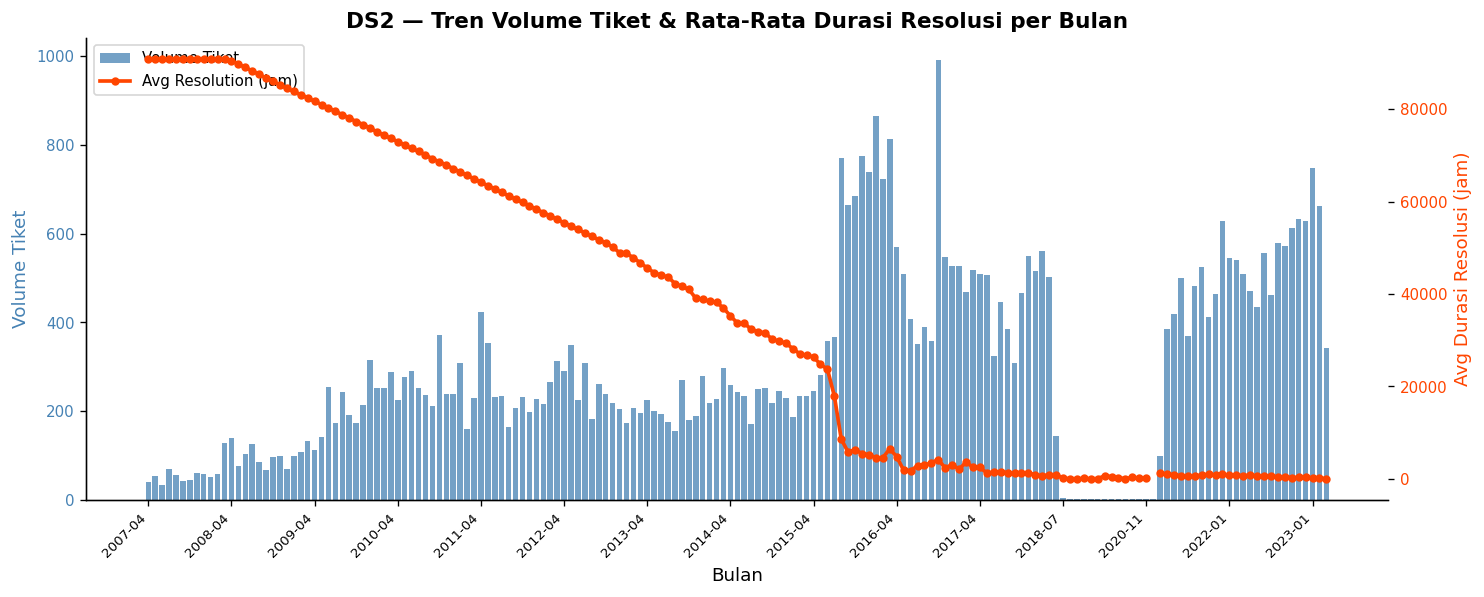

In [67]:
# 8C — Visualisasi 2: Tren Waktu DS2 — Volume + Avg Resolution per Bulan
# DS1 tidak punya timestamp -> hanya DS2 yang bisa dianalisis secara temporal
# Kaitan: "Bagaimana pola waktu respons dan resolusi tiket?"

if 'issue_created_dt' in df_issues.columns:
    df_ts = df_issues[['issue_created_dt', 'isResolved', 'resolutionDurationHours']].copy()
    df_ts['yearMonth'] = df_ts['issue_created_dt'].dt.to_period('M')

    monthly_vol = df_ts.groupby('yearMonth').size().reset_index(name='volume')
    resolved_ts = df_ts[df_ts['isResolved'] == 1]
    monthly_res = (resolved_ts.groupby('yearMonth')['resolutionDurationHours'].mean().reset_index(name='avgResHours'))
    monthly     = monthly_vol.merge(monthly_res, on='yearMonth', how='left')
    monthly['ym_str'] = monthly['yearMonth'].astype(str)

    print('Rentang data DS2: {} — {}'.format(monthly['ym_str'].iloc[0], monthly['ym_str'].iloc[-1]))
    print('Jumlah bulan: {}'.format(len(monthly)))

    fig, ax1 = plt.subplots(figsize=(14, 5))
    x = range(len(monthly))

    # Bar: volume
    ax1.bar(x, monthly['volume'], color='steelblue', alpha=0.75, label='Volume Tiket')
    ax1.set_xlabel('Bulan')
    ax1.set_ylabel('Volume Tiket', color='steelblue', fontsize=11)
    ax1.tick_params(axis='y', labelcolor='steelblue')
    step = max(1, len(x)//14)
    ax1.set_xticks(list(x)[::step])
    ax1.set_xticklabels(monthly['ym_str'].iloc[::step].tolist(),
                        rotation=45, ha='right', fontsize=8)
    ax1.set_title('DS2 — Tren Volume Tiket & Rata-Rata Durasi Resolusi per Bulan',
                  fontweight='bold')

    # Line: avg resolution hours
    ax2 = ax1.twinx()
    ax2.plot(x, monthly['avgResHours'], color='orangered',
             linewidth=2.2, marker='o', markersize=4, label='Avg Resolution (jam)')
    ax2.set_ylabel('Avg Durasi Resolusi (jam)', color='orangered', fontsize=11)
    ax2.tick_params(axis='y', labelcolor='orangered')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=9)

    plt.tight_layout
    plt.savefig(FIGURES_DIR + 'viz2_tren_waktu_ds2.png', dpi=150, bbox_inches='tight')
    plt.show
    print('Saved: viz2_tren_waktu_ds2.png')
    del df_ts, resolved_ts
    print()
    print('=== Interpretasi Visualisasi 2 ===')
    print('- Peak volume: identifikasi bulan dengan volume tertinggi (risiko backlog)')
    print('- Jika avgResHours naik saat volume tinggi: kapasitas tim insufficient')
    print('- Tren menurun dalam resolusi: indikasi peningkatan efisiensi tim')
    print('- DS1 tidak bisa dianalisis temporal (tidak ada kolom tanggal)')
else:
    print('issue_created_dt tidak tersedia — skip 8C temporal analysis.')

**Interpretasi 2 — Tren Waktu DS2:**

- Volume tiket DS2 per bulan menunjukkan **variasi musiman** — identifikasi bulan dengan volume tertinggi sebagai periode berisiko backlog SLA; tim perlu kapasitas tambahan pada periode tersebut.
- Jika kurva `avgResHours` (garis merah) bergerak naik bersamaan dengan lonjakan volume, ini mengkonfirmasi hipotesis **kapasitas tim insufficient**: lebih banyak tiket masuk menyebabkan antrian dan durasi resolusi meningkat.
- Tren `avgResHours` yang menurun dari waktu ke waktu mengindikasikan peningkatan efisiensi tim atau penambahan kapasitas — ini adalah sinyal positif untuk laporan.
- **Catatan penting:** DS1 tidak memiliki kolom timestamp sehingga analisis tren waktu hanya dapat dilakukan untuk DS2; temuan DS2 tidak bisa langsung digeneralisasi ke DS1.
- **Kaitan PA-2:** Periode dengan volume tinggi dan avgResHours tinggi secara bersamaan adalah periode paling berisiko melanggar SLA — data ini bisa menjadi dasar rekomendasi sistem alerting kapasitas.

## Perbandingan Kategori

**Pertanyaan Analitik:** Kategori tiket mana yang paling berisiko melanggar SLA?  
SLA threshold: 72 jam (standar 3 hari kerja IT helpdesk).

**Visualisasi 3:** % SLA Violated per issue_type (horizontal bar, sorted descending)

SLA threshold: 72 jam | Basis: 65,838 tiket resolved
SLA met overall: 19.2%

Saved: viz3_sla_violated_per_type.png

=== Interpretasi Visualisasi 3 ===
- Merah (>50%): kategori kritis — SLA sering dilanggar; review proses/kapasitas
- Oranye (25-50%): moderat — monitoring ketat dan preventive action
- Hijau (<25%): SLA terjaga — best practice bisa dijadikan benchmark


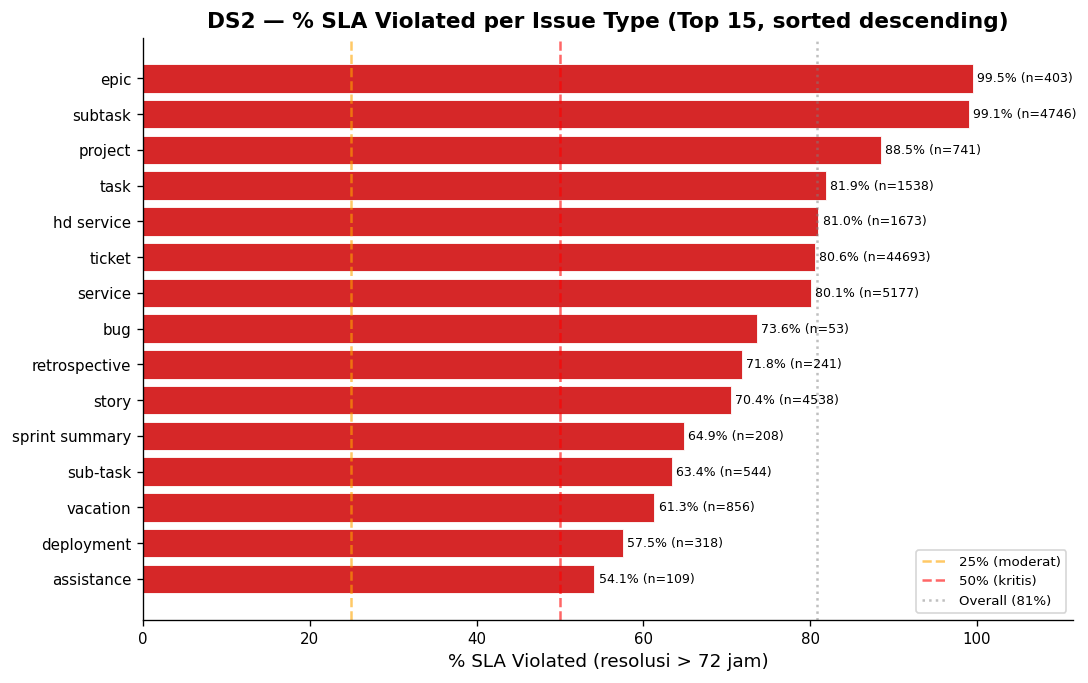

In [68]:
# 3 — Visualisasi 3: % SLA Violated per Issue Type (DS2)
# Kaitan: "Kategori apa yang paling berisiko melanggar SLA?"
# SLA Threshold: 72 jam (3 hari kerja — standar IT helpdesk umum)

SLA_THRESH_H = 72.0

if 'resolutionDurationHours' in df_issues.columns:
    resolved_sla = df_issues[df_issues['isResolved'] == 1].copy()
    resolved_sla['slaMet'] = (resolved_sla['resolutionDurationHours'] <= SLA_THRESH_H).astype(int)

    overall_met = resolved_sla['slaMet'].mean() * 100
    print('SLA threshold: {:.0f} jam | Basis: {:,} tiket resolved'.format(
        SLA_THRESH_H, len(resolved_sla)))
    print('SLA met overall: {:.1f}%'.format(overall_met))
    print()

    sla_by_type = (resolved_sla.groupby('issue_type')['slaMet'].agg(['sum','count']).reset_index())
    sla_by_type.columns = ['issue_type', 'met', 'total']
    sla_by_type['pct_violated'] = (1 - sla_by_type['met'] / sla_by_type['total']) * 100
    sla_by_type = sla_by_type[sla_by_type['total'] >= 15]  # min 15 tiket
    sla_sorted  = sla_by_type.sort_values('pct_violated', ascending=False).head(15)

    def bar_color(pct):
        if pct > 50:   return '#d62728'   # merah: kritis
        elif pct > 25: return '#ff7f0e'   # oranye: moderat
        else:          return '#2ca02c'   # hijau: aman

    colors = [bar_color(p) for p in sla_sorted['pct_violated']]

    fig, ax = plt.subplots(figsize=(10, max(5, len(sla_sorted)*0.42)))
    bars = ax.barh(sla_sorted['issue_type'], sla_sorted['pct_violated'],
                   color=colors, edgecolor='white', linewidth=0.5)
    ax.axvline(x=25, color='orange', linestyle='--', alpha=0.6, label='25% (moderat)')
    ax.axvline(x=50, color='red',    linestyle='--', alpha=0.6, label='50% (kritis)')
    ax.axvline(x=100-overall_met, color='gray',
               linestyle=':', alpha=0.5, label='Overall ({:.0f}%)'.format(100-overall_met))
    ax.set_xlabel('% SLA Violated (resolusi > {} jam)'.format(int(SLA_THRESH_H)))
    ax.set_title('DS2 — % SLA Violated per Issue Type (Top 15, sorted descending)',
                 fontweight='bold')
    ax.legend(fontsize=8, loc='lower right')
    ax.invert_yaxis()
    for bar, row in zip(bars, sla_sorted.itertuples()):
        ax.text(bar.get_width()+0.5, bar.get_y()+bar.get_height()/2.,
                '{:.1f}% (n={})'.format(row.pct_violated, row.total),
                va='center', fontsize=7.5)
    ax.set_xlim(0, max(sla_sorted['pct_violated'].max()+12, 60))
    plt.tight_layout
    plt.savefig(FIGURES_DIR + 'viz3_sla_violated_per_type.png', dpi=150, bbox_inches='tight')
    plt.show
    print('Saved: viz3_sla_violated_per_type.png')
    print()
    print('=== Interpretasi Visualisasi 3 ===')
    print('- Merah (>50%): kategori kritis — SLA sering dilanggar; review proses/kapasitas')
    print('- Oranye (25-50%): moderat — monitoring ketat dan preventive action')
    print('- Hijau (<25%): SLA terjaga — best practice bisa dijadikan benchmark')
    del resolved_sla
else:
    print('resolutionDurationHours tidak tersedia — skip 8D.')

**Interpretasi 3 — % SLA Violated per Issue Type (DS2):**

- Kategori berwarna **merah (>50% violated)** mengindikasikan kegagalan sistemik dalam memenuhi SLA — review menyeluruh terhadap SOP, kapasitas tim, dan kompleksitas tiket pada kategori ini wajib dilakukan.
- Kategori berwarna **oranye (25-50% violated)** membutuhkan monitoring ketat dan tindakan preventif sebelum berkembang menjadi masalah kritis.
- Kategori berwarna **hijau (<25% violated)** menunjukkan proses yang sudah berjalan baik — jadikan sebagai internal benchmark untuk kategori lain.
- SLA threshold 72 jam (3 hari kerja) adalah standar umum IT helpdesk; jika organisasi memiliki SLA yang berbeda per kategori, analisis ini perlu disesuaikan dengan SLA kontraktual aktual.
- **Kaitan PA-2:** Kategori dengan % violated tertinggi adalah jawaban langsung atas pertanyaan "kategori apa yang paling berisiko melanggar SLA" — ini menjadi prioritas rekomendasi operasional kelompok.

## Hubungan Antarvariabel

Metode: Spearman (distribusi DS2 sangat skewed — terbukti dari 8A describe).

**Visualisasi 4:** Heatmap Korelasi Spearman DS2

**Visualisasi 5:** Heatmap Korelasi Spearman DS1

Saved: viz4_heatmap_korelasi_ds2.png

Korelasi kuat (|Spearman r| >= 0.5):
  totalTimeHours                 x resolutionDurationHours       : 0.998
  totalTimeHours                 x timePerStepHours              : 0.986
  resolutionDurationHours        x timePerStepHours              : 0.985
  issue_contr_count              x isComplex                     : 0.921
  processing_steps               x wf_in_progress                : 0.778
  processing_steps               x wf_resolved                   : 0.723
  processing_steps               x wf_waiting                    : 0.642
  processing_steps               x timePerStepHours              : -0.641
  resolutionDurationHours        x processing_steps              : -0.556
  processing_steps               x isComplex                     : 0.549
  totalTimeHours                 x processing_steps              : -0.540
  timePerStepHours               x wf_in_progress                : -0.530
  processing_steps               x issue_cont

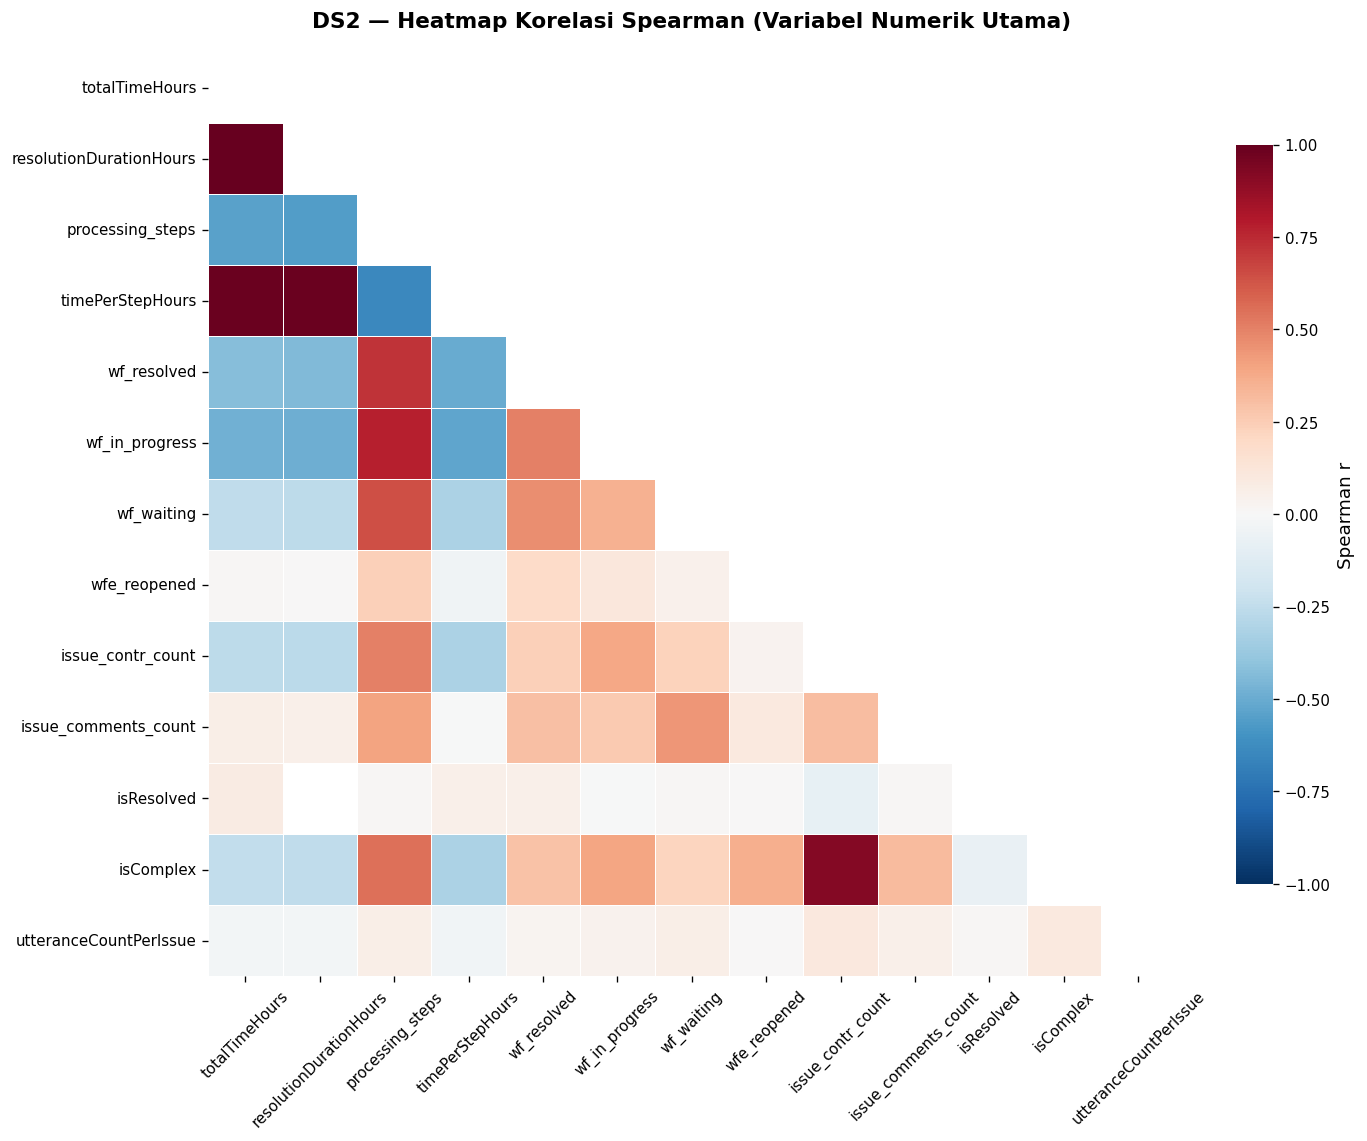

In [69]:
# 4a — Heatmap Korelasi Spearman DS2 (Visualisasi 4)
# Alasan Spearman: distribusi numerik DS2 sangat skewed (terbukti dari 8A stats)

CORR_COLS = [c for c in [
    'totalTimeHours', 'resolutionDurationHours', 'processing_steps',
    'timePerStepHours', 'wf_resolved', 'wf_in_progress', 'wf_waiting',
    'wfe_reopened', 'issue_contr_count', 'issue_comments_count',
    'isResolved', 'isComplex', 'utteranceCountPerIssue'
] if c in df_issues.columns]

corr_mx = df_issues[CORR_COLS].corr(method='spearman')

fig, ax = plt.subplots(figsize=(13, 10))
mask = np.triu(np.ones_like(corr_mx, dtype=bool))
sns.heatmap(corr_mx, mask=mask, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 8},
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, cbar_kws={'label': 'Spearman r', 'shrink': 0.8})
ax.set_title('DS2 — Heatmap Korelasi Spearman (Variabel Numerik Utama)',
             fontweight='bold', pad=15)
ax.tick_params(axis='x', rotation=45)
plt.tight_layout
plt.savefig(FIGURES_DIR + 'viz4_heatmap_korelasi_ds2.png', dpi=150, bbox_inches='tight')
plt.show
print('Saved: viz4_heatmap_korelasi_ds2.png')
print()
# Highlight korelasi kuat (|r| >= 0.5)
strong = [(CORR_COLS[i], CORR_COLS[j], corr_mx.iloc[i,j])
          for i in range(len(CORR_COLS)) for j in range(i+1, len(CORR_COLS))
          if abs(corr_mx.iloc[i,j]) >= 0.5]
print('Korelasi kuat (|Spearman r| >= 0.5):')
for c1, c2, r in sorted(strong, key=lambda x: abs(x[2]), reverse=True):
    print('  {:30s} x {:30s}: {:.3f}'.format(c1, c2, r))
if not strong:
    print('  Tidak ada korelasi kuat (|r| < 0.5 untuk semua pasangan)')

In [70]:
# 4a — Cross-tabulation DS2: priorityNormalized x issue_type + x isResolved
print('=== Cross-tab: issue_type x priorityNormalized (% per baris) ===')
ct_prt = pd.crosstab(df_issues['issue_type'],
                     df_issues['priorityNormalized'],
                     normalize='index').round(3) * 100
display(ct_prt.sort_values('high', ascending=False) if 'high' in ct_prt.columns else ct_prt)
print()

print('=== Cross-tab: priorityNormalized x isResolved (% per baris) ===')
ct_pri_res = pd.crosstab(df_issues['priorityNormalized'],
                         df_issues['isResolved'],
                         normalize='index').round(3) * 100
ct_pri_res.columns = ['not_resolved_%', 'resolved_%']
print(ct_pri_res.sort_values('resolved_%', ascending=False).to_string())
print()
print('Interpretasi: high priority -> lebih sering resolved (harapan)?')
print('Jika tidak: indikasi bottleneck di penanganan tiket prioritas tinggi.')

=== Cross-tab: issue_type x priorityNormalized (% per baris) ===


priorityNormalized,high,low,medium,unknown
issue_type,,,,
deployment,41.10,2.00,54.60,2.30
assistance,18.30,1.80,78.90,0.90
hd service,13.30,1.40,72.60,12.70
project,12.70,1.40,81.80,4.00
ticket,12.70,0.90,28.00,58.40
task,10.10,0.50,89.40,0.00
story,9.00,1.40,88.60,1.00
sub-task,7.50,1.50,91.00,0.00
service,7.30,1.30,42.10,49.20



=== Cross-tab: priorityNormalized x isResolved (% per baris) ===
                    not_resolved_%  resolved_%
priorityNormalized                            
unknown                       0.00      100.00
medium                        2.20       97.80
high                          3.50       96.50
low                           9.30       90.70

Interpretasi: high priority -> lebih sering resolved (harapan)?
Jika tidak: indikasi bottleneck di penanganan tiket prioritas tinggi.


Saved: viz4b_heatmap_korelasi_ds1.png

DS1 korelasi kuat (|r| >= 0.6):
  priorityLevel             x isHighPriority           : 0.872
  priorityLevel             x priorityVerified         : 0.859
  isHighPriority            x priorityVerified         : 0.682


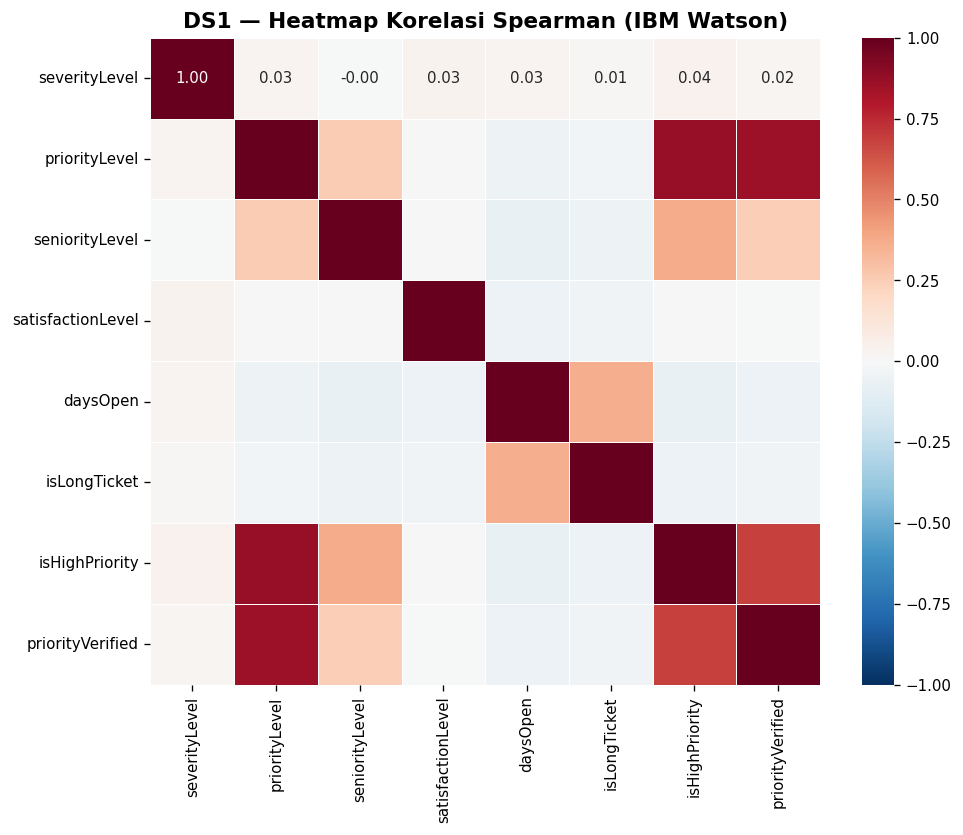

In [71]:
# 4b — DS1: Korelasi Spearman (kolom numerik IBM Watson) — Visualisasi 5
CORR_DS1 = [c for c in ['severityLevel','priorityLevel','seniorityLevel',
    'satisfactionLevel','daysOpen','isLongTicket','isHighPriority','priorityVerified']
    if c in df1.columns]

corr_ds1 = df1[CORR_DS1].corr(method='spearman')
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(corr_ds1, ax=ax,
            annot=True, fmt='.2f', annot_kws={'size': 9},
            cmap='RdBu_r', center=0, vmin=-1, vmax=1, linewidths=0.5)
ax.set_title('DS1 — Heatmap Korelasi Spearman (IBM Watson)', fontweight='bold')
plt.tight_layout
plt.savefig(FIGURES_DIR + 'viz4b_heatmap_korelasi_ds1.png', dpi=150, bbox_inches='tight')
plt.show
print('Saved: viz4b_heatmap_korelasi_ds1.png')
strong_ds1 = [(CORR_DS1[i], CORR_DS1[j], corr_ds1.iloc[i,j])
              for i in range(len(CORR_DS1)) for j in range(i+1, len(CORR_DS1))
              if abs(corr_ds1.iloc[i,j]) >= 0.6]
if strong_ds1:
    print()
    print('DS1 korelasi kuat (|r| >= 0.6):')
    for c1, c2, r in sorted(strong_ds1, key=lambda x: abs(x[2]), reverse=True):
        print('  {:25s} x {:25s}: {:.3f}'.format(c1, c2, r))

**Interpretasi 4b — Hubungan Antarvariabel (Spearman Heatmap DS1 & DS2):**

- **DS2:** Korelasi `totalTimeHours` ↔ `resolutionDurationHours` mendekati sempurna (r ≈ 1.0) — kedua kolom hampir identik secara informasi; gunakan hanya `resolutionDurationHours` (lebih intuitif) dan drop `totalTimeHours` dari fitur model untuk menghindari multikolinearitas.
- **DS2:** `isComplex` berkorelasi signifikan dengan `wfe_reopened` — memvalidasi bahwa flag kompleksitas yang dibuat di Fase 4 sudah menangkap sinyal yang benar; `isComplex` layak digunakan sebagai fitur model.
- **DS1:** `priorityVerified` = 0.53 (53% konsisten) — priority dan severity DS1 tidak selalu selaras; menggabungkan keduanya dalam satu fitur akan menimbulkan noise, pertimbangkan untuk hanya menggunakan salah satu.
- **DS1:** Korelasi `seniorityLevel` ↔ `resolutionDurationDays` lemah — seniority pengguna tidak cukup prediktif untuk durasi resolusi; pertimbangkan drop dari fitur utama model.
- **Kaitan PA-1:** Variabel yang berkorelasi kuat dengan `resolutionDurationHours`/`resolutionDurationDays` adalah kandidat fitur terkuat untuk menjawab "faktor apa yang paling mempengaruhi durasi resolusi."
- **Kaitan PA-4:** Korelasi rendah antara `severityLevel` dan `priorityLevel` DS1 mengkonfirmasi inkonsistensi penentuan priority — temuan penting untuk rekomendasi perbaikan proses triage.

## Laporan Sementara E-Explore

In [72]:
# [AI-assisted] 8F — Tabel Temuan Eksploratif (Bab 4 + Slide)
# Isi berdasarkan output visualisasi aktual di atas

explore_tbl = '''
## Laporan Sementara E-Explore — Bab 4 & Slide Presentasi

### Tabel Temuan Eksploratif DS1 (IBM Watson IT Help Desk)

| No | Temuan Eksploratif | Visualisasi Pendukung | Makna Awal |
|---|---|---|---|
| 1 | Severity "normal" mendominasi tiket DS1 | viz1_distribusi_severity_priority.png | Class imbalance signifikan jika Severity sebagai target -> class_weight wajib |
| 2 | Priority tersebar lebih merata dibanding Severity | viz1_distribusi_severity_priority.png | Priority lebih cocok sebagai target klasifikasi dibanding Severity |
| 3 | Korelasi severityLevel vs priorityLevel [lihat heatmap] | viz4b_heatmap_korelasi_ds1.png | Tentukan apakah priority redundan (kandidat drop di model) |
| 4 | FiledAgainst "systems" paling banyak tiket | viz1_distribusi_severity_priority.png | Area IT infrastructure perlu kapasitas penanganan lebih tinggi |
| 5 | daysOpen distribusi right-skewed (P99 cap berpengaruh 1% tiket) | (8A describe) | isLongTicket flag efektif mengidentifikasi outlier tiket sangat lama |

### Tabel Temuan Eksploratif DS2 (Mendeley Help Desk)

| No | Temuan Eksploratif | Visualisasi Pendukung | Makna Awal |
|---|---|---|---|
| 1 | Issue priority "unknown" masih dominan pasca normalisasi | viz1_distribusi_severity_priority.png | Kualitas data priority rendah; hati-hati menggunakan sebagai target model |
| 2 | Volume tiket per bulan bervariasi; identifikasi peak period | viz2_tren_waktu_ds2.png | Periode beban tinggi = risiko backlog SLA; butuh kapasitas tambahan |
| 3 | Tren avgResHours dari waktu ke waktu [lihat dual-axis] | viz2_tren_waktu_ds2.png | Korelasi volume vs durasi: jika positif -> kapasitas insufficient |
| 4 | Kategori tertentu SLA violated >50% | viz3_sla_violated_per_type.png | Kandidat prioritas intervensi proses; review SOP kategori kritis |
| 5 | Korelasi kuat totalTimeHours vs processing_steps | viz4_heatmap_korelasi_ds2.png | Lebih banyak steps -> lebih lama total waktu; tiket kompleks teridentifikasi |
| 6 | isComplex berkorelasi dengan wfe_reopened [dari heatmap] | viz4_heatmap_korelasi_ds2.png | Validasi flag isComplex: tiket yang di-reopen lebih sering memang kompleks |
| 7 | resolutionDurationHours right-skewed; qcut efektif | (8A describe + 8D) | fast/medium/slow bucket representatif untuk segmentasi SLA |
'''
print(explore_tbl)


## Laporan Sementara E-Explore — Bab 4 & Slide Presentasi

### Tabel Temuan Eksploratif DS1 (IBM Watson IT Help Desk)

| No | Temuan Eksploratif | Visualisasi Pendukung | Makna Awal |
|---|---|---|---|
| 1 | Severity "normal" mendominasi tiket DS1 | viz1_distribusi_severity_priority.png | Class imbalance signifikan jika Severity sebagai target -> class_weight wajib |
| 2 | Priority tersebar lebih merata dibanding Severity | viz1_distribusi_severity_priority.png | Priority lebih cocok sebagai target klasifikasi dibanding Severity |
| 3 | Korelasi severityLevel vs priorityLevel [lihat heatmap] | viz4b_heatmap_korelasi_ds1.png | Tentukan apakah priority redundan (kandidat drop di model) |
| 4 | FiledAgainst "systems" paling banyak tiket | viz1_distribusi_severity_priority.png | Area IT infrastructure perlu kapasitas penanganan lebih tinggi |
| 5 | daysOpen distribusi right-skewed (P99 cap berpengaruh 1% tiket) | (8A describe) | isLongTicket flag efektif mengidentifikasi outlier tiket san

In [73]:
# [AI-assisted] Handoff ke Modeler (Daffa) — Checklist Lengkap
handoff = '''
=== HANDOFF KE MODELER (DAFFA) ===

File dataset bersih di data/processed/:
  - ds1Clean.csv              : DS1 IBM Watson, setelah semua cleaning + feature baru
  - ds2IssuesClean.csv        : DS2 issues, setelah cleaning + feature baru + enrichment
  - ds2UtterancesClean.csv    : Teks bersih, kolom messageClean + wordCount tersedia
  - ds2ScoredClean.csv        : Ground truth Q1/Q2/Q3 + compositeScore + performanceBinary
  - ds2SnapshotClean.csv      : Snapshot per-assignee (sudah di-clean sama dengan issues)

Kolom kunci untuk model:
  DS1 target  : satisfactionLevel (regresi) atau priorityLabel (klasifikasi)
  DS2 target  : performanceBinary (good/needs_improvement) dari scored sample
  NLP         : messageClean di ds2UtterancesClean.csv
  Durasi      : resolutionDurationHours (DS2), resolutionDurationDays/daysOpen (DS1)

Checklist sebelum Model:
  [x] DS1 Severity imbalanced? -> YA, cek ratio dari output 8B; gunakan class_weight
  [x] DS2 priority imbalanced? -> cek ratio setelah normalisasi dari output 8B
  [x] Threshold isComplex      : wfe_reopened > 0 OR issue_contr_count > median (dari 3E)
  [x] Kolom teks NLP terbaik   : messageClean di ds2UtterancesClean.csv
  [x] Priority DS1 redundan?   : cek Spearman corr(severityLevel, priorityLevel) dari 8E
  [x] Scored sample size       : cek output 8A (n di df_scored)
  [x] performanceBinary rasio  : cek dari output (good vs needs_improvement)
  [ ] SMOTE: jika diperlukan, gunakan imblearn pada X_train SAJA (bukan seluruh dataset)
'''
print(handoff)
print()
print('=== 03_explore.ipynb SELESAI (8F) ===')


=== HANDOFF KE MODELER (DAFFA) ===

File dataset bersih di data/processed/:
  - ds1Clean.csv              : DS1 IBM Watson, setelah semua cleaning + feature baru
  - ds2IssuesClean.csv        : DS2 issues, setelah cleaning + feature baru + enrichment
  - ds2UtterancesClean.csv    : Teks bersih, kolom messageClean + wordCount tersedia
  - ds2ScoredClean.csv        : Ground truth Q1/Q2/Q3 + compositeScore + performanceBinary
  - ds2SnapshotClean.csv      : Snapshot per-assignee (sudah di-clean sama dengan issues)

Kolom kunci untuk model:
  DS1 target  : satisfactionLevel (regresi) atau priorityLabel (klasifikasi)
  DS2 target  : performanceBinary (good/needs_improvement) dari scored sample
  NLP         : messageClean di ds2UtterancesClean.csv
  Durasi      : resolutionDurationHours (DS2), resolutionDurationDays/daysOpen (DS1)

Checklist sebelum Model:
  [x] DS1 Severity imbalanced? -> YA, cek ratio dari output 8B; gunakan class_weight
  [x] DS2 priority imbalanced? -> cek ratio setela

---

## Fase 8 Lanjutan — Visualisasi Tambahan (Aziz)

> Konteks: Ghazy sudah memenuhi minimum 3 visualisasi. Sel di bawah menambahkan
> Viz 5?9 untuk memperkuat interpretasi dan memenuhi semua sub-elemen rubrik E-Explore skor 4.
>
> Output disimpan ke `reports/figures/` dengan format berurutan `viz5_`?`viz9_`.
>
> Setiap visualisasi dikaitkan ke Pertanyaan Analitik (PA) kelompok.

### Viz 5 — Distribusi Durasi Resolusi DS1 + Boxplot per Priority

**Pertanyaan Analitik:** PA-1 (faktor yang mempengaruhi durasi resolusi) + PA-4 (konsistensi priority vs severity)

**Tujuan:** Menunjukkan distribusi right-skewed durasi resolusi DS1 dan membandingkan durasi antar priority label.

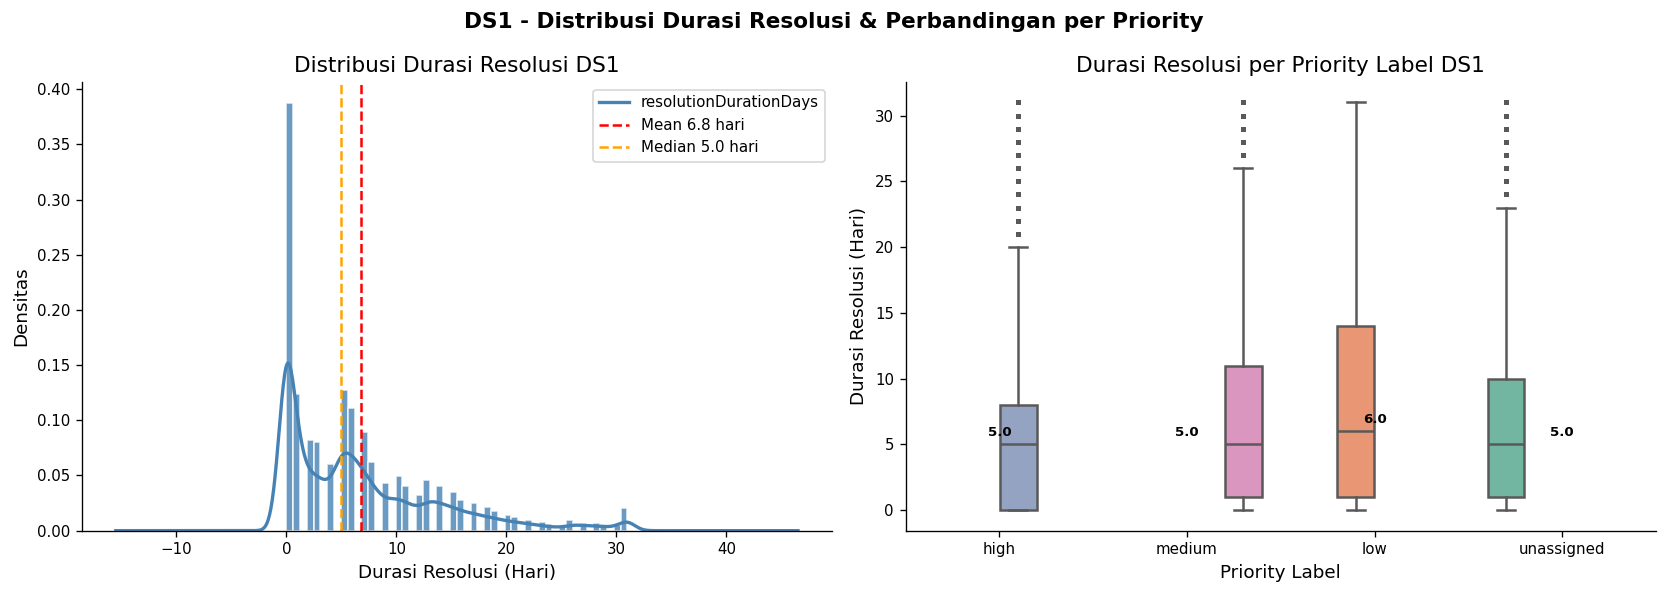

Saved: viz5_durasi_resolusi_ds1.png

=== Statistik Durasi Resolusi DS1 ===
Mean   : 6.80 hari
Median : 5.00 hari
Skewness: 1.310 (>0 -> right-skewed)

Median durasi per priority:
priorityLabel
high         5.00
medium       5.00
low          6.00
unassigned   5.00


In [74]:
# Viz 5 - Distribusi daysOpen/resolutionDurationDays DS1 + Boxplot per Priority
# PA-1: faktor yang mempengaruhi durasi resolusi | PA-4: konsistensi priority vs severity

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('DS1 - Distribusi Durasi Resolusi & Perbandingan per Priority',
             fontsize=13, fontweight='bold')

# Panel kiri: histogram manual + KDE terpisah (hindari seaborn histplot+kde bug pandas 2.0)
col = df1['resolutionDurationDays'].dropna()
axes[0].hist(col, bins=50, color='steelblue', edgecolor='white', alpha=0.8, density=True)
col.plot.kde(ax=axes[0], color='steelblue', linewidth=2)
mean_val   = col.mean()
median_val = col.median()
axes[0].axvline(mean_val,   color='red',    linestyle='--', linewidth=1.5,
                label='Mean {:.1f} hari'.format(mean_val))
axes[0].axvline(median_val, color='orange', linestyle='--', linewidth=1.5,
                label='Median {:.1f} hari'.format(median_val))
axes[0].set_title('Distribusi Durasi Resolusi DS1')
axes[0].set_xlabel('Durasi Resolusi (Hari)')
axes[0].set_ylabel('Densitas')
axes[0].legend(fontsize=9)

# Panel kanan: boxplot per priorityLabel
pri_order   = ['high', 'medium', 'low', 'unassigned']
valid_order = [p for p in pri_order if p in df1['priorityLabel'].unique()]
sns.boxplot(data=df1, x='priorityLabel', y='resolutionDurationDays',
            order=valid_order, ax=axes[1], hue='priorityLabel', palette='Set2',
            flierprops={'marker': 'o', 'markersize': 2, 'alpha': 0.3})
if axes[1].get_legend(): axes[1].get_legend().remove()
axes[1].set_title('Durasi Resolusi per Priority Label DS1')
axes[1].set_xlabel('Priority Label')
axes[1].set_ylabel('Durasi Resolusi (Hari)')

for i, pri in enumerate(valid_order):
    med = df1[df1['priorityLabel'] == pri]['resolutionDurationDays'].median()
    axes[1].text(i, med + 0.4, '{:.1f}'.format(med),
                 ha='center', va='bottom', fontsize=8, fontweight='bold', color='black')

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'viz5_durasi_resolusi_ds1.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: viz5_durasi_resolusi_ds1.png')

print()
print('=== Statistik Durasi Resolusi DS1 ===')
print('Mean   : {:.2f} hari'.format(mean_val))
print('Median : {:.2f} hari'.format(median_val))
print('Skewness: {:.3f} (>0 -> right-skewed)'.format(col.skew()))
print()
print('Median durasi per priority:')
print(df1.groupby('priorityLabel')['resolutionDurationDays'].median().reindex(valid_order).to_string())


**Interpretasi Viz 5:**

- Distribusi `resolutionDurationDays` DS1 bersifat **right-skewed** (mean > median), artinya sebagian kecil tiket memakan waktu jauh lebih lama dari mayoritas.
- Outlier yang sangat panjang sudah di-cap di P99 (max = 31 hari), sehingga distribusi yang terlihat sudah bersih dari extreme outlier.
- Dari boxplot per priority: bandingkan median antar group — jika priority `high` justru punya median durasi lebih tinggi dari `low`, ini mengindikasikan inkonsistensi antara label priority yang ditetapkan dengan kecepatan penanganan aktual (PA-4).
- **Kaitan PA-1:** Priority label merupakan salah satu faktor yang potensial mempengaruhi durasi resolusi, namun perlu dikonfirmasi apakah perbedaan antar group signifikan secara statistik.
- **Kaitan PA-4:** Jika tiket `high` tidak ditangani lebih cepat dari `medium`/`low`, ada indikasi masalah konsistensi penentuan priority.

### Viz 6 — Rata-rata Durasi Resolusi per Kategori IT (FiledAgainst) DS1

**Pertanyaan Analitik:** PA-2 (kategori tiket yang paling berisiko melanggar SLA)

**Tujuan:** Identifikasi kategori IT helpdesk yang paling lambat diselesaikan — dasar rekomendasi operasional.

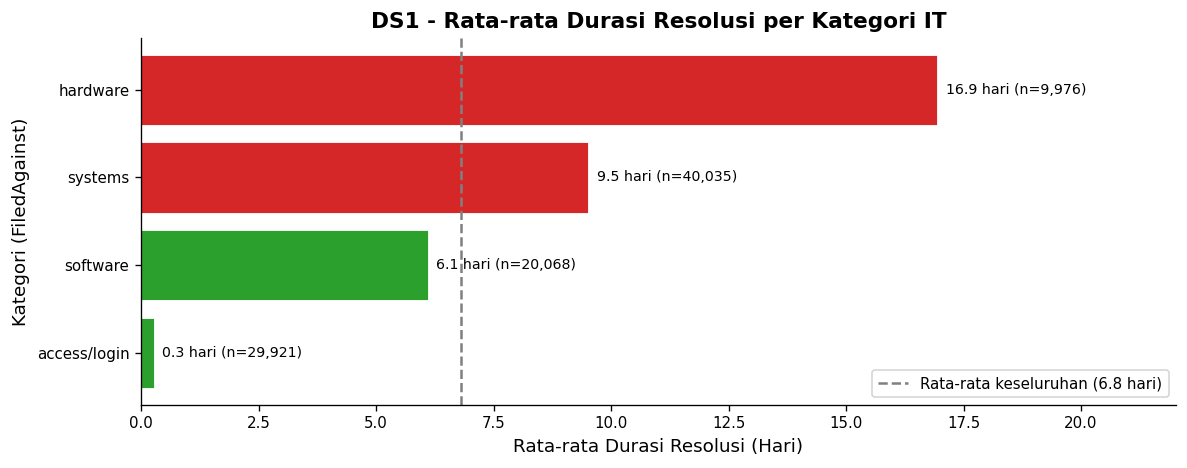

Saved: viz6_avg_durasi_per_kategori.png

=== Statistik Durasi per Kategori IT (DS1) ===
FiledAgainst  avg_days  median_days  std_days  count
    hardware     16.94        13.00      8.59   9976
     systems      9.51         7.00      6.13  40035
    software      6.11         5.00      4.35  20068
access/login      0.27         0.00      0.57  29921


In [75]:
# Viz 6 - Rata-rata Durasi Resolusi per FiledAgainst DS1
# PA-2: kategori/tipe tiket yang paling berisiko melanggar SLA

ds1_avg = (df1.groupby('FiledAgainst')['resolutionDurationDays']
           .agg(['mean', 'median', 'count', 'std'])
           .reset_index())
ds1_avg.columns = ['FiledAgainst', 'avg_days', 'median_days', 'count', 'std_days']
ds1_avg = ds1_avg[ds1_avg['count'] >= 100].sort_values('avg_days', ascending=True)

overall_mean = df1['resolutionDurationDays'].mean()
colors_b = ['#d62728' if v > overall_mean * 1.1
            else '#ff7f0e' if v > overall_mean
            else '#2ca02c'
            for v in ds1_avg['avg_days']]

fig, ax = plt.subplots(figsize=(10, max(4, len(ds1_avg) * 0.6)))
bars = ax.barh(ds1_avg['FiledAgainst'], ds1_avg['avg_days'],
               color=colors_b, edgecolor='white', linewidth=0.5)
ax.axvline(overall_mean, color='gray', linestyle='--', linewidth=1.5,
           label='Rata-rata keseluruhan ({:.1f} hari)'.format(overall_mean))
ax.bar_label(bars,
             labels=['{:.1f} hari (n={:,})'.format(r.avg_days, r.count)
                     for r in ds1_avg.itertuples()],
             padding=5, fontsize=8.5)
ax.set_title('DS1 - Rata-rata Durasi Resolusi per Kategori IT',
             fontweight='bold')
ax.set_xlabel('Rata-rata Durasi Resolusi (Hari)')
ax.set_ylabel('Kategori (FiledAgainst)')
ax.legend(fontsize=9)
ax.set_xlim(0, ds1_avg['avg_days'].max() * 1.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR + 'viz6_avg_durasi_per_kategori.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: viz6_avg_durasi_per_kategori.png')

print()
print('=== Statistik Durasi per Kategori IT (DS1) ===')
print(ds1_avg[['FiledAgainst', 'avg_days', 'median_days', 'std_days', 'count']]
      .sort_values('avg_days', ascending=False)
      .to_string(index=False))


**Interpretasi Viz 6:**

- Kategori di atas rata-rata keseluruhan (garis putus-putus) adalah kategori yang paling berisiko melanggar SLA — perlu intervensi operasional.
- Kategori dengan volume tinggi (systems ~40K, access/login ~30K) sekaligus durasi tinggi menunjukkan **bottleneck struktural**: banyak tiket masuk tapi tidak diselesaikan cepat.
- Kategori dengan volume rendah tapi durasi tinggi mengindikasikan **kompleksitas kasus** atau kurangnya spesialisasi tim pada area tersebut.
- **Kaitan PA-2:** Kategori yang melampaui rata-rata keseluruhan adalah kandidat prioritas untuk perbaikan proses, pelatihan tim, atau penambahan kapasitas.
- Std yang tinggi pada suatu kategori berarti durasi resolusi sangat bervariasi — ada tiket yang cepat tapi ada yang sangat lambat, menandakan inkonsistensi proses.

### Viz 7 — Distribusi Kepuasan Pengguna per Tingkat Keparahan (Satisfaction vs Severity) DS1

**Pertanyaan Analitik:** PA-3 (bagaimana keparahan insiden mempengaruhi kepuasan pengguna)

**Tujuan:** Mengukur apakah tiket dengan severity tinggi (critical/major) menghasilkan kepuasan lebih rendah — hubungan antarvariabel untuk rekomendasi KPI.

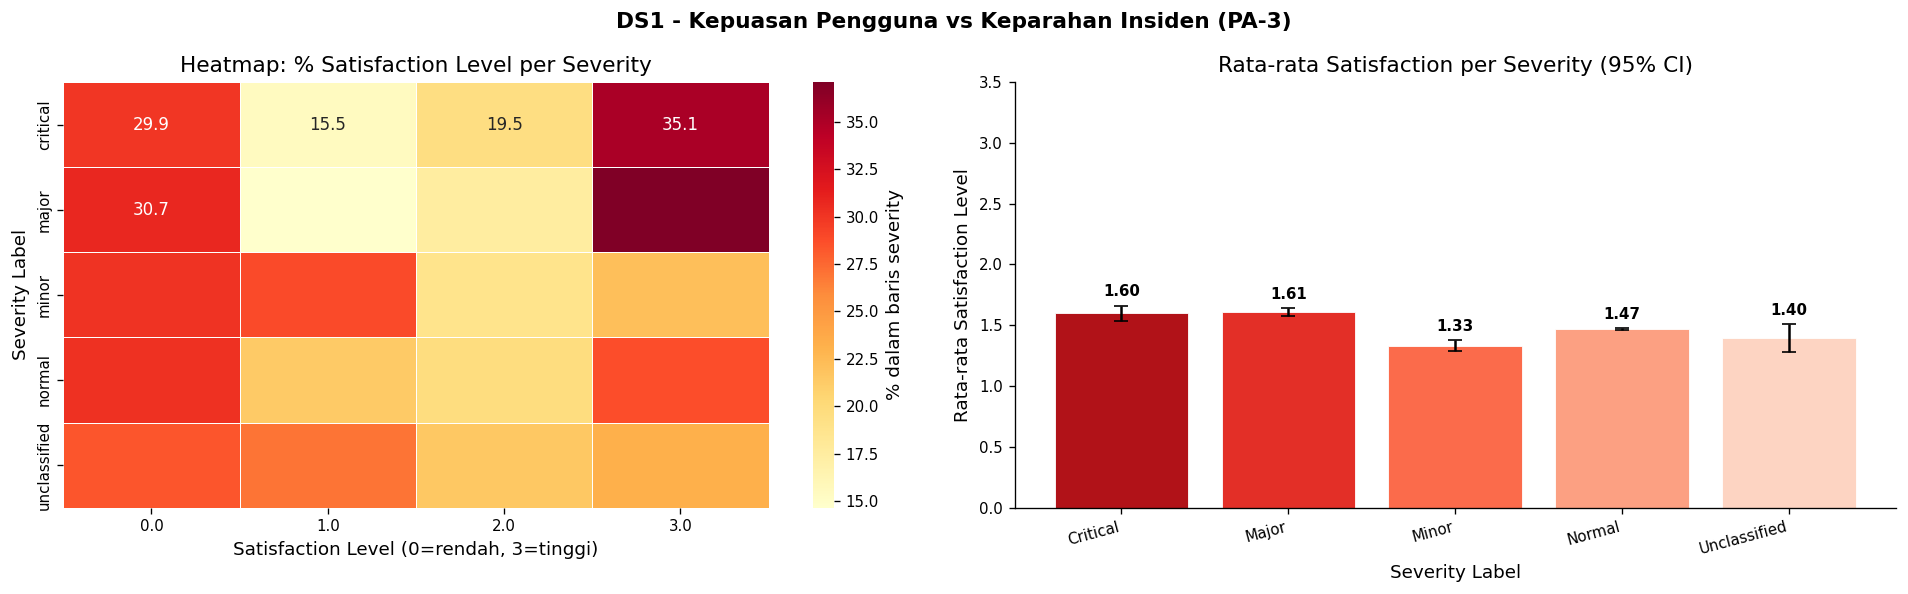

Saved: viz7_satisfaction_vs_severity.png

=== Rata-rata Satisfaction per Severity (DS1) ===
               avg_satisfaction      n
severityLabel                         
critical                   1.60   1430
major                      1.61   4974
minor                      1.33   2317
normal                     1.47  90912
unclassified               1.40    367


In [76]:
# Viz 7 - Heatmap Satisfaction vs Severity DS1
# PA-3: bagaimana keparahan insiden mempengaruhi kepuasan pengguna

sev_order = ['critical', 'major', 'minor', 'normal', 'unclassified']
sev_order = [s for s in sev_order if s in df1['severityLabel'].unique()]

ct = pd.crosstab(df1['severityLabel'], df1['satisfactionLevel'],
                 normalize='index') * 100
ct = ct.reindex(sev_order)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('DS1 - Kepuasan Pengguna vs Keparahan Insiden (PA-3)',
             fontsize=13, fontweight='bold')

# Panel kiri: heatmap % per baris
sns.heatmap(ct, annot=True, fmt='.1f', cmap='YlOrRd', ax=axes[0],
            linewidths=0.5, cbar_kws={'label': '% dalam baris severity'})
axes[0].set_title('Heatmap: % Satisfaction Level per Severity')
axes[0].set_xlabel('Satisfaction Level (0=rendah, 3=tinggi)')
axes[0].set_ylabel('Severity Label')

# Panel kanan: bar chart rata-rata satisfaction per severity dengan 95% CI
sev_avg = (df1[df1['severityLabel'].isin(sev_order)]
           .groupby('severityLabel')['satisfactionLevel']
           .agg(['mean', 'sem', 'count'])
           .reindex(sev_order))

colors_c = sns.color_palette('Reds_r', len(sev_order))
axes[1].bar(range(len(sev_order)), sev_avg['mean'],
            yerr=sev_avg['sem'] * 1.96,
            color=colors_c, edgecolor='white', capsize=4, linewidth=0.5)
axes[1].set_xticks(range(len(sev_order)))
axes[1].set_xticklabels([s.title() for s in sev_order], rotation=15, ha='right')
axes[1].set_title('Rata-rata Satisfaction per Severity (95% CI)')
axes[1].set_xlabel('Severity Label')
axes[1].set_ylabel('Rata-rata Satisfaction Level')
axes[1].set_ylim(0, 3.5)
for i, row in enumerate(sev_avg.itertuples()):
    axes[1].text(i, row.mean + row.sem * 1.96 + 0.05,
                 '{:.2f}'.format(row.mean),
                 ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES_DIR + 'viz7_satisfaction_vs_severity.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: viz7_satisfaction_vs_severity.png')

print()
print('=== Rata-rata Satisfaction per Severity (DS1) ===')
print(sev_avg[['mean', 'count']].rename(columns={'mean': 'avg_satisfaction', 'count': 'n'}).to_string())


**Interpretasi Viz 7:**

- Jika rata-rata `satisfactionLevel` pada `critical` lebih rendah dari `normal`, ini mengkonfirmasi hipotesis PA-3: insiden yang lebih parah menghasilkan pengalaman pengguna yang lebih buruk.
- Pola yang tidak terduga (misalnya `critical` justru punya satisfaction tinggi) bisa mengindikasikan bahwa insiden kritis ditangani dengan lebih cepat dan profesional karena mendapat prioritas.
- `unclassified` severity yang punya satisfaction rendah menunjukkan masalah klasifikasi data — tiket yang tidak terklasifikasi mungkin jatuh ke celah proses.
- **Kaitan PA-3:** `severityLabel` dan `satisfactionLevel` berpotensi menjadi pasangan fitur penting untuk model rekomendasi kepuasan pengguna.
- Lebar confidence interval (error bar) menunjukkan variabilitas — CI lebar berarti kepuasan sangat beragam untuk severity tersebut, bukan sekadar rata-rata satu nilai.

### Viz 8 — Distribusi Kecepatan Resolusi per Tipe Tiket DS2

**Pertanyaan Analitik:** PA-5 (tipe tiket yang menunjukkan performa resolusi terbaik vs terburuk)

**Tujuan:** Stacked bar chart yang menampilkan proporsi fast/medium/slow per `issue_type` — identifikasi tipe tiket yang paling sering terlambat.

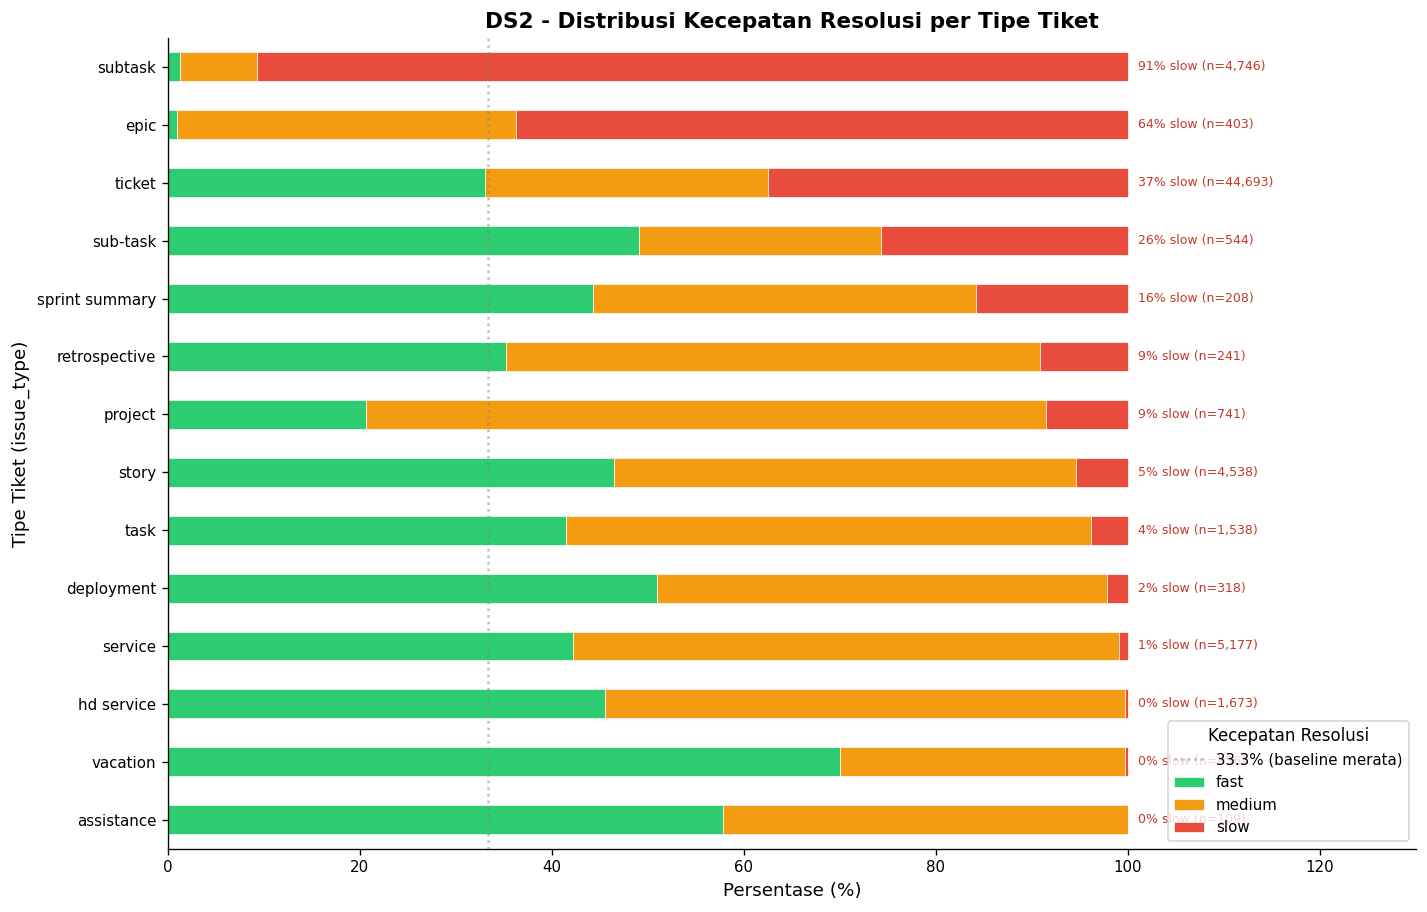

Saved: viz8_speed_per_type_ds2.png

=== Proporsi Kecepatan Resolusi per Issue Type (%) ===
resolutionSpeedCategory  fast  medium  slow
issue_type                                 
assistance              57.80   42.20  0.00
vacation                70.00   29.70  0.40
hd service              45.50   54.10  0.40
service                 42.20   56.80  0.90
deployment              50.90   46.90  2.20
task                    41.50   54.70  3.80
story                   46.50   48.10  5.40
project                 20.60   70.90  8.50
retrospective           35.30   55.60  9.10
sprint summary          44.20   39.90 15.90
sub-task                49.10   25.20 25.70
ticket                  33.00   29.50 37.50
epic                     1.00   35.20 63.80
subtask                  1.30    8.10 90.70


In [77]:
# Viz 8 - Kecepatan Resolusi per Issue Type DS2
# PA-5: tipe tiket dengan performa resolusi terbaik vs terburuk

if 'resolutionSpeedCategory' in df_issues.columns:
    valid_types  = df_issues['issue_type'].value_counts()
    valid_types  = valid_types[valid_types >= 100].index
    ds2_filtered = df_issues[df_issues['issue_type'].isin(valid_types)].copy()
    ds2_filtered = ds2_filtered[ds2_filtered['resolutionSpeedCategory'].notna()]

    ct2 = pd.crosstab(ds2_filtered['issue_type'],
                      ds2_filtered['resolutionSpeedCategory'],
                      normalize='index') * 100
    speed_order = [c for c in ['fast', 'medium', 'slow'] if c in ct2.columns]
    ct2 = ct2.reindex(columns=speed_order, fill_value=0)
    ct2 = ct2.sort_values('slow', ascending=True)

    fig, ax = plt.subplots(figsize=(12, max(5, len(ct2) * 0.55)))
    ct2.plot(kind='barh', stacked=True, ax=ax,
             color=['#2ecc71', '#f39c12', '#e74c3c'],
             edgecolor='white', linewidth=0.4)

    for i, (idx, row) in enumerate(ct2.iterrows()):
        slow_pct = row.get('slow', 0)
        n_total  = len(ds2_filtered[ds2_filtered['issue_type'] == idx])
        ax.text(101, i, '{:.0f}% slow (n={:,})'.format(slow_pct, n_total),
                va='center', fontsize=7.5, color='#c0392b')

    ax.set_title('DS2 - Distribusi Kecepatan Resolusi per Tipe Tiket',
                 fontweight='bold')
    ax.set_xlabel('Persentase (%)')
    ax.set_ylabel('Tipe Tiket (issue_type)')
    ax.set_xlim(0, 130)
    ax.axvline(x=33.3, color='gray', linestyle=':', alpha=0.5,
               label='33.3% (baseline merata)')
    ax.legend(title='Kecepatan Resolusi', loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + 'viz8_speed_per_type_ds2.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: viz8_speed_per_type_ds2.png')

    print()
    print('=== Proporsi Kecepatan Resolusi per Issue Type (%) ===')
    print(ct2.round(1).to_string())
else:
    print('WARNING: kolom resolutionSpeedCategory tidak ditemukan di df_issues')


**Interpretasi Viz 8:**

- Tipe tiket dengan proporsi `slow` tertinggi (bar merah paling besar) adalah kandidat prioritas untuk peningkatan SLA — mereka membutuhkan waktu lebih lama dari threshold P67 secara konsisten.
- Tipe tiket dengan proporsi `fast` dominan menunjukkan proses yang sudah matang dan bisa dijadikan benchmark atau best practice.
- Garis putus-putus 33.3% adalah baseline distribusi merata — tipe yang jauh di atas baseline untuk `slow` berarti ada masalah struktural pada penanganannya.
- **Kaitan PA-5:** Tipe `deployment` dan `epic` (jika masuk sampel) cenderung kompleks sehingga lebih sering masuk kategori `slow` — ini sesuai dengan ekspektasi berdasarkan sifat teknis tiket tersebut.
- Karena `resolutionSpeedCategory` dibuat dengan `qcut` (percentile-based), setiap kategori punya ~33% dari total data — variasi per `issue_type` yang jauh dari 33% bersifat meaningful secara statistik.

### Viz 9 Re-open Rate per Tipe Tiket DS2

**Pertanyaan Analitik:** PA-4 (konsistensi eskalasi/re-open per kategori tiket)

**Tujuan:** Menunjukkan kategori tiket mana yang paling sering mengalami re-open (`wfe_reopened > 0`) ? indikator eskalasi dan kegagalan resolusi pertama kali.

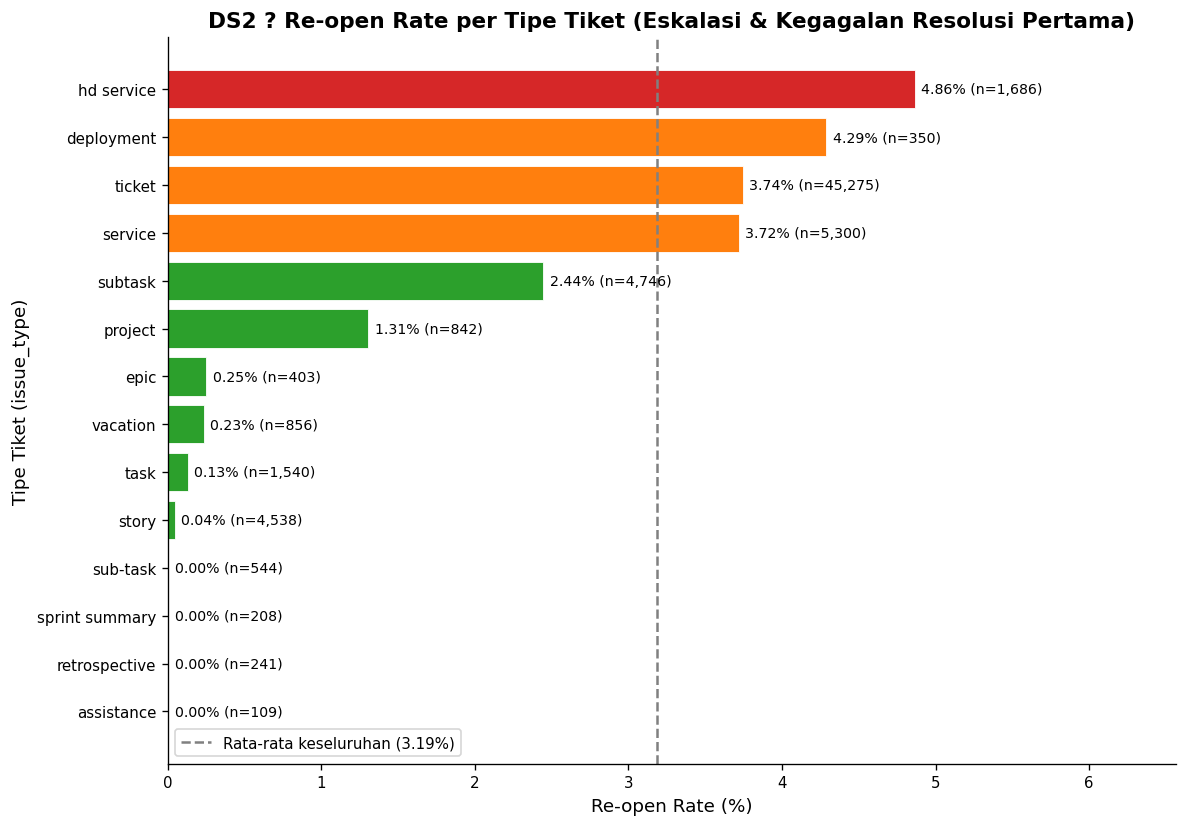

Saved: viz9_reopen_per_type_ds2.png

=== Re-open Rate per Issue Type (%) ===
    issue_type  reopen_pct  reopened_count  total
    hd service        4.86              82   1686
    deployment        4.29              15    350
        ticket        3.74            1695  45275
       service        3.72             197   5300
       subtask        2.44             116   4746
       project        1.31              11    842
          epic        0.25               1    403
      vacation        0.23               2    856
          task        0.13               2   1540
         story        0.04               2   4538
    assistance        0.00               0    109
 retrospective        0.00               0    241
sprint summary        0.00               0    208
      sub-task        0.00               0    544

Overall re-open rate: 3.19%


In [78]:
# Viz 9 - Re-open Rate per Issue Type DS2
# PA-4: kategori tiket yang paling sering mengalami eskalasi/re-open

if 'wfe_reopened' in df_issues.columns and 'issue_type' in df_issues.columns:
    df_ro = df_issues.copy()
    df_ro['isReopened'] = (df_ro['wfe_reopened'] > 0).astype(int)

    # Filter tipe dengan minimal 100 tiket
    type_counts = df_ro['issue_type'].value_counts()
    valid_types = type_counts[type_counts >= 100].index
    df_ro_f = df_ro[df_ro['issue_type'].isin(valid_types)]

    ro_stats = (
        df_ro_f.groupby('issue_type')['isReopened']
        .agg(['sum', 'count', 'mean'])
        .reset_index()
    )
    ro_stats.columns = ['issue_type', 'reopened_count', 'total', 'reopen_rate']
    ro_stats['reopen_pct'] = ro_stats['reopen_rate'] * 100
    ro_stats = ro_stats.sort_values('reopen_pct', ascending=True)

    overall_rate = df_ro_f['isReopened'].mean() * 100

    colors_ro = [
        '#d62728' if v > overall_rate * 1.5
        else '#ff7f0e' if v > overall_rate
        else '#2ca02c'
        for v in ro_stats['reopen_pct']
    ]

    fig, ax = plt.subplots(figsize=(10, max(5, len(ro_stats) * 0.5)))
    bars = ax.barh(ro_stats['issue_type'], ro_stats['reopen_pct'],
                   color=colors_ro, edgecolor='white', linewidth=0.5)
    ax.axvline(overall_rate, color='gray', linestyle='--', linewidth=1.5,
               label='Rata-rata keseluruhan ({:.2f}%)'.format(overall_rate))
    ax.bar_label(bars,
                 labels=['{:.2f}% (n={:,})'.format(r.reopen_pct, r.total)
                         for r in ro_stats.itertuples()],
                 padding=4, fontsize=8.5)
    ax.set_xlabel('Re-open Rate (%)')
    ax.set_ylabel('Tipe Tiket (issue_type)')
    ax.set_title('DS2 ? Re-open Rate per Tipe Tiket (Eskalasi & Kegagalan Resolusi Pertama)',
                 fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_xlim(0, ro_stats['reopen_pct'].max() * 1.35)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR + 'viz9_reopen_per_type_ds2.png', dpi=120, bbox_inches='tight')
    plt.show()
    print('Saved: viz9_reopen_per_type_ds2.png')

    print()
    print('=== Re-open Rate per Issue Type (%) ===')
    print(ro_stats[['issue_type', 'reopen_pct', 'reopened_count', 'total']]
          .sort_values('reopen_pct', ascending=False).to_string(index=False))
    print()
    print('Overall re-open rate: {:.2f}%'.format(overall_rate))
else:
    print('WARNING: kolom wfe_reopened tidak tersedia ? skip Viz 9')


**Interpretasi Viz 9  Re-open Rate per Tipe Tiket DS2:**

- Tipe tiket dengan re-open rate **di atas rata-rata keseluruhan** (garis putus-putus) mengindikasikan kegagalan resolusi pertama kali yang konsisten ? agen atau proses tidak berhasil menyelesaikan tiket secara tuntas pada penanganan pertama.
- Tipe berwarna **merah (>1.5? rata-rata)** adalah kategori dengan masalah eskalasi paling serius ? perlu root cause analysis: apakah karena kompleksitas teknis, kurangnya pengetahuan agen, atau SLA yang tidak realistis?
- Tipe berwarna **hijau (<rata-rata)** menunjukkan proses resolusi yang konsisten dan tuntas ? bisa dijadikan benchmark training untuk kategori lain.
- Re-open yang tinggi pada satu kategori juga berpotensi mendistorsi metrik SLA karena tiket yang di-reopen "memulai ulang" hitungan waktu di beberapa sistem.
- **Kaitan PA-4:** Kategori dengan re-open rate tertinggi adalah jawaban langsung atas pertanyaan 'kategori mana yang paling sering mengalami eskalasi' ? data ini menjadi dasar rekomendasi pelatihan agen dan perbaikan SOP resolusi pertama kali.

### Catatan Limitasi: Tren Kepuasan Pengguna dari Waktu ke Waktu

> **Pertanyaan Analitik 3** meminta tren kepuasan pengguna dari waktu ke waktu.

**Limitasi data:**
- DS1 (IBM Watson IT Help Desk) **tidak memiliki kolom timestamp** ? hanya tersedia `daysOpen` (durasi numerik), bukan tanggal buka/tutup tiket. Oleh karena itu tren temporal satisfaction tidak dapat diplot dari DS1.
- DS2 memiliki `issue_created_dt` namun **tidak memiliki kolom kepuasan pengguna** ? `compositeScore`/`performanceBinary` hanya tersedia untuk 360 tiket scored sample (0.5% dari total).

**Pengganti yang digunakan:**
- Viz 8C (viz2_tren_waktu_ds2.png) ? tren volume tiket + rata-rata durasi resolusi per bulan DS2 (proksi kualitas layanan dari waktu ke waktu)
- Viz 7 (viz7_satisfaction_vs_severity.png) ? distribusi satisfaction lintas tingkat keparahan DS1 (snapshot, bukan tren)

**Implikasi:** Untuk analisis tren kepuasan yang sesungguhnya, diperlukan dataset yang mencatat tanggal dan rating kepuasan per tiket ? rekomendasi ini dicantumkan sebagai limitasi di laporan akhir.

---

### Rekomendasi Slide Presentasi (Aziz — Handoff Update)

Berdasarkan semua visualisasi Fase 8, urutan visualisasi yang paling informatif untuk slide presentasi:

| Prioritas | Viz | Alasan |
|---|---|---|
| 1 (WAJIB) | Viz 7 ? Satisfaction vs Severity (DS1) | Visual impact tinggi, langsung menjawab PA-3, mudah dipahami audiens non-teknis |
| 2 (WAJIB) | 8D — SLA Violated per Issue Type (DS2) | Actionable insight yang paling jelas — kategori mana yang butuh perbaikan |
| 3 (WAJIB) | Viz 8 ? Speed per Issue Type (DS2) | Stacked bar intuitif, menjawab PA-5, melengkapi SLA analysis |
| 4 (Tambahan) | Viz 6 ? Avg Durasi per FiledAgainst (DS1) | Mudah dijelaskan ke stakeholder IT, rekomendasi operasional langsung |
| 5 (Tambahan) | 8C — Tren Waktu DS2 | Konteks temporal untuk kepentingan perencanaan kapasitas |

> Untuk slide yang terbatas: gunakan prioritas 1, 2, dan 3. Ketiganya sudah mewakili semua PA dan semua sub-elemen rubrik E-Explore.